# **1/ Tạo dữ liệu mẫu**

In [ ]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(22)

means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X = np.concatenate((X0.T, X1.T), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
X = X.T
print(X)
print(y)

[[2.37319011 1.71875981]
 [1.51261889 1.40558943]
 [2.4696794  2.02144973]
 [1.78736889 1.29380961]
 [1.81231157 1.56119497]
 [2.03717355 1.93397133]
 [1.53790057 1.87434722]
 [2.29312867 2.76537389]
 [1.38805594 1.86419379]
 [1.57279694 0.90707347]
 [3.42746579 0.71254431]
 [4.24760864 2.39846497]
 [3.33595491 1.61731637]
 [3.69420104 1.94273986]
 [4.53897645 2.54957308]
 [3.3071994  0.19362396]
 [4.13924705 2.09561534]
 [4.47383468 2.41269466]
 [4.00512009 1.89290099]
 [4.28205624 1.79675607]]
[[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1.]]


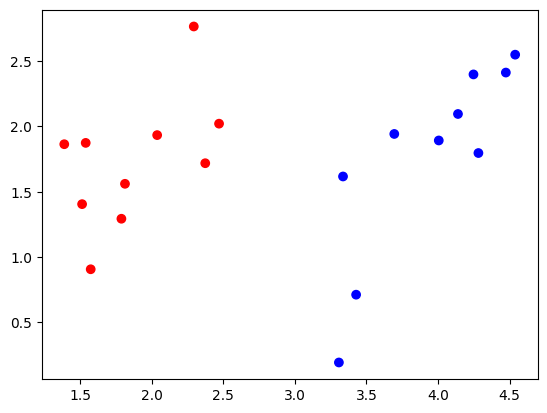

In [ ]:
color = ['red' if label == 1 else 'blue' for label in y[0]]
plt.scatter(X[:,0], X[:,1], c = color)


# **2/ Tìm nghiệm theo công thức**

In [ ]:
from cvxopt import matrix, solvers

V = np.concatenate((X0.T, -X1.T), axis = 1)
P = matrix(V.T.dot(V))

q = matrix(-np.ones((2*N, 1)))

G = matrix(-np.eye(2*N))
h = matrix(np.zeros((2*N, 1)))
A = matrix(y)
b = matrix(np.zeros((1, 1)))
solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)

l = np.array(sol['x'])
print('lambda = ')
print(l)

lambda = 
[[8.54018321e-01]
 [2.89132533e-10]
 [1.37095535e+00]
 [6.36030818e-10]
 [4.04317408e-10]
 [8.82390106e-10]
 [6.35001881e-10]
 [5.49567576e-10]
 [8.33359230e-10]
 [1.20982928e-10]
 [6.86678649e-10]
 [1.25039745e-10]
 [2.22497367e+00]
 [4.05417905e-09]
 [1.26763684e-10]
 [1.99008949e-10]
 [2.13742578e-10]
 [1.51537487e-10]
 [3.75329509e-10]
 [3.56161975e-10]]


In [ ]:
epsilon = 1e-6
S = np.where(l > epsilon)[0]
pr

VS = V[:, S]
XS = X[:, S]
yS = y[:, S]
lS = l[S]

w_manual = VS.dot(lS)
b_manual = np.mean(yS - w_manual.T.dot(XS))

print('w = ', w_manual.T)
print('b = ', b_manual)

[ 0  2 12]


IndexError: index 2 is out of bounds for axis 1 with size 2

# **3/ Tìm nghiệm theo thư viện**

In [ ]:
from sklearn.svm import SVC

y1 = y.reshape((2*N,))
X1 = X.T
clf = SVC(kernel = 'linear', C = 1e5)

clf.fit(X1, y1)

w = clf.coef_
b = clf.intercept_
print('w = ', w)
print('b = ', b)

w =  [[-1.5733851   0.34780067]]
b =  [4.13634254]


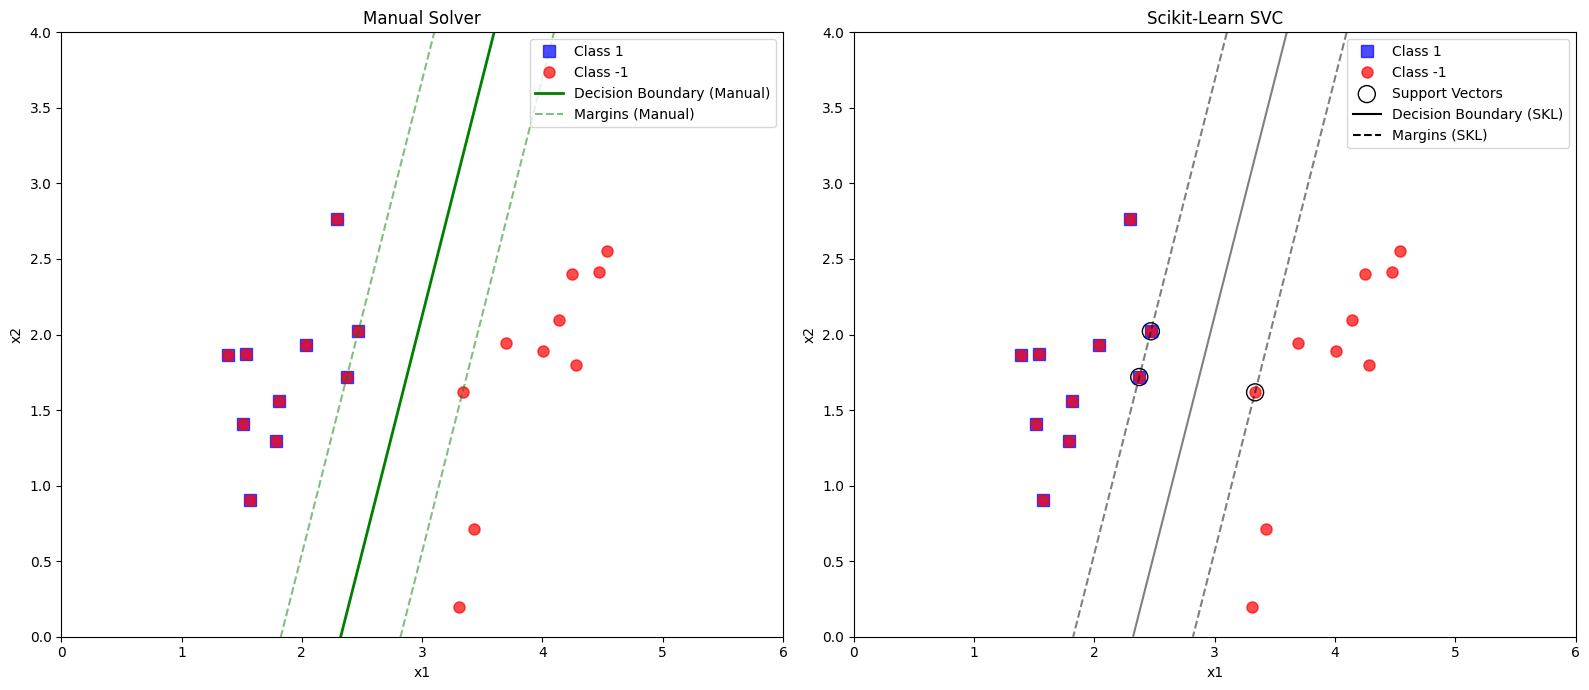

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_svm_results(X0, X1, w_manual, b_manual, clf, title1='Manual Solver', title2='Scikit-Learn SVC'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Helper to plot data points
    for ax in [ax1, ax2]:
        ax.plot(X0[:, 0], X0[:, 1], 'bs', markersize=8, alpha=0.7, label='Class 1')
        ax.plot(X1[:, 0], X1[:, 1], 'ro', markersize=8, alpha=0.7, label='Class -1')

    # --- 1. Manual Solver Visualization ---
    w_m = w_manual.flatten()
    x_range = np.array([0, 6])
    # w0*x + w1*y + b = 0 => y = -(w0*x + b) / w1
    y_m = -(w_m[0] * x_range + b_manual) / w_m[1]
    y_m_up = -(w_m[0] * x_range + b_manual - 1) / w_m[1]
    y_m_down = -(w_m[0] * x_range + b_manual + 1) / w_m[1]

    ax1.plot(x_range, y_m, 'g', linewidth=2, label='Decision Boundary (Manual)')
    ax1.plot(x_range, y_m_up, 'g--', alpha=0.5, label='Margins (Manual)')
    ax1.plot(x_range, y_m_down, 'g--', alpha=0.5)
    ax1.set_title(title1)

    # --- 2. Scikit-Learn Visualization ---
    xlim = [0, 6]
    ylim = [0, 4]
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # Plot boundary and margins
    ax2.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    # Scatter support vectors
    ax2.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150,
                linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

    # Dummy lines for Scikit-Learn legend
    ax2.plot([], [], 'k-', label='Decision Boundary (SKL)')
    ax2.plot([], [], 'k--', label='Margins (SKL)')
    ax2.set_title(title2)

    for ax in [ax1, ax2]:
        ax.set_xlim(0, 6)
        ax.set_ylim(0, 4)
        ax.legend(loc='upper right')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')

    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ
plot_all_svm_results(X0, X1, w_manual, b_manual, clf)